In [633]:
%load_ext jupyter_black

The jupyter_black extension is already loaded. To reload it, use:
  %reload_ext jupyter_black


In [634]:
import matplotlib.pyplot as plt
import numpy as np
from itertools import product
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from scipy.optimize import minimize_scalar
from sklearn.cluster import DBSCAN

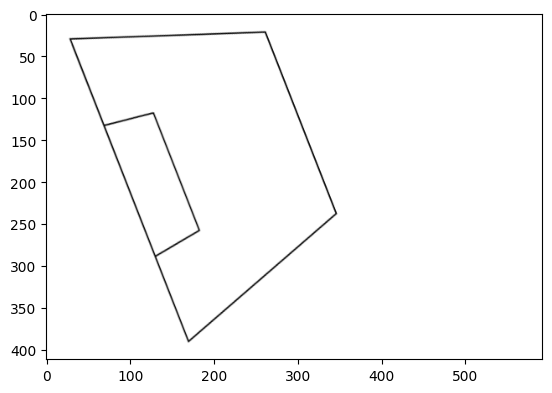

In [635]:
# 1 - Récupération de l'image
img_array = plt.imread(
    r"C:\Users\John\Desktop\jupyter_notebooks\Porosimetre\data\image_050326.png"
)
img_array = img_array[:, :, 0]  # Convertir en niveaux de gris

plt.imshow(img_array, cmap="gray")

array([[-193.6478083 ,   79.37570758],
       [ 195.2041864 ,   80.83386345],
       [-116.67623333, -141.82866997],
       [ 117.67354452, -141.40249624],
       [   0.4986556 , -141.61558311],
       [ -86.        ,   76.        ],
       [  88.        ,   77.        ],
       [ -77.        ,   19.        ],
       [  76.        ,   17.        ],
       [  -0.5       ,   18.        ]])

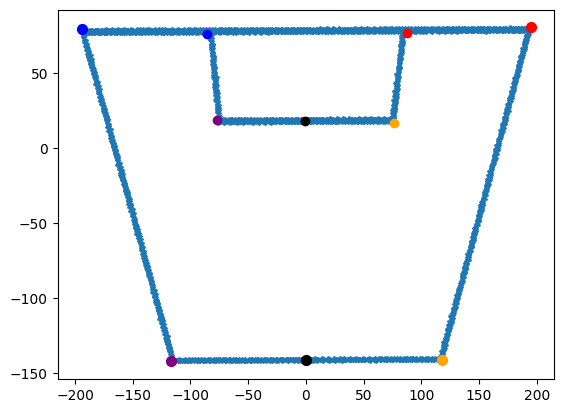

In [656]:
def erode_line(figure, A, B, grind):
    "Cette fonction permet d'éroder un segment AB. Il prend un segment AB en entrée et fait le produit vectoriel de AB avec Ap"
    "où p est un point de la figure pour calculer la distance de p à AB. "
    "Si la distance est supérieur à grind le point et conservé"
    "args : figure (np.array) : l'ensemble des points de la figure"
    "       A (np.array) : une extrémité du segment"
    "       B (np.array) : l'autre extrémité du segment"
    "       grind (int) : l'épaisseur du trait à éroder"
    "returns : (np.array) : la figure avec AB érodé"
    erosion = []
    for p in figure:
        if np.linalg.norm(np.cross(B - A, p - A)) / np.linalg.norm(B - A) < grind:
            continue
        else:
            erosion.append(p)
    return np.array(erosion)


def erode_line_2(figure, iter):
    "Cette fonction permet d'éroder une figure. Il prend chaque colonne une par une"
    "et enlève un point d'indice de ligne max et d'indice de ligne min et retourne la figure érodée"
    "args : figure (np.array) : l'ensemble des points de la figure"
    "       iter (int): le nombre de cycle d'érosion"
    "returns : (np.array) : la figure érodée"
    fig = figure.copy()
    for i, j in product(range(iter), range(fig.shape[1])):
        try:
            sup = np.max(np.where(fig[:, j] != 1))
            inf = np.min(np.where(fig[:, j] != 1))
            fig[sup, j] = 1
            fig[inf, j] = 1
        except:
            continue
        i += 1
    return fig


def extract_cluster(img_pca, grind, eps, min_samples):
    "Cette fonction retransforme la liste des coordonnées img_pca en tableau image, pour pouvoir l'éroder avec erode_line_2"
    "Puis la retransforme en coordonnées et lui applique un dbscan pour extraire le petit parallélogramme"
    "args : img_pca (np.array) : liste des coordonnées"
    "       grind (int) : l'épaisseur d'érosion du contour"
    "       eps (int) : le rayon de la fenêtre dbscan"
    "       min_samples : l'effectif mini dans la fenêtre dbscan"
    "returns : (np.array) un tableau de coordonnées du petit parallélogramme"
    # Erosion du contour pour atteindre le petit parallélogramme
    y_coords = img_pca[:, 0].astype(int)
    x_coords = img_pca[:, 1].astype(int)
    x_coords_min = np.min(x_coords)
    y_coords_min = np.min(y_coords)
    x_coords = x_coords - x_coords_min
    y_coords = y_coords - y_coords_min

    # Les dimensions maximales
    max_x = np.max(x_coords) + 1
    max_y = np.max(y_coords) + 1

    # On crée un masque de 1
    tableau_2d = np.ones((max_x, max_y), dtype=int)

    # On met à 0 les coordonnées (x, y)
    tableau_2d[x_coords, y_coords] = 0

    # plt.imshow(tableau_2d)
    # On effecture l'érosion du contour
    petit_carré = erode_line_2(tableau_2d, grind)

    # On revient au format initial
    h, w = petit_carré.shape
    petit_carré = np.array(
        [[j, i] for i, j in product(range(h), range(w)) if (petit_carré[i, j] != 1)]
    )
    # Et un dbscan pour isoler le petit carré
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    dbscan.fit(petit_carré)

    # Visualisation
    labels = dbscan.labels_
    # scatter = plt.scatter(petit_carré[:, 0], petit_carré[:, 1], c=labels)

    # Le petit carré
    petit_carré = petit_carré[labels == 0]
    petit_carré[:, 0] += y_coords_min
    petit_carré[:, 1] += x_coords_min

    # plt.scatter(petit_carré[:, 0], petit_carré[:, 1], s=1)
    return petit_carré


def fit_transform(path, axis=-1):
    "Cette fonction prend une image en entrée, la transforme en np.array et lui applique un pca"
    "args : path (str) : le chemin vers l'image d'entrée"
    "       axis (int) : -1 retourne l'axe de l'image transformée par pca, 0 la laisse telle quelle"
    "       m (int): l'épaisseur du trait pour retirer les côtés du grand parallélogramme"
    "returns : img_array (np.array) : l'image transformée"

    # image -> img_array
    img_array = plt.imread(path)
    img_array = img_array[:, :, 0]

    # erosion du contour extérieur de l'image
    # img_array = erode_line_2(img_array, 3)

    # pca
    h, w = img_array.shape
    img_points = np.array(
        [[j, i] for i, j in product(range(h), range(w)) if (img_array[i, j] != 1)]
    )
    pca = PCA()
    img_pca = pca.fit_transform(img_points)
    img_pca[:, 1] = axis * img_pca[:, 1]
    plt.scatter(img_pca[:, 0], img_pca[:, 1], s=1)
    return img_pca


def labels(img_pca, grind=4):
    "Cette fonction calcule les points d'intérêt de l'image img_pca"
    "args : img_pca (np.array) : l'image d'entrée"
    "       grind (int): l'épaisseur du trait pour retirer les côtés du grand parallélogramme"
    "returns : labels (np.array) : les coordonnées des point caractéristiques"
    # Coordonnées des points A et B sur la ligne du haut et C et D du bas
    top_line = np.array(
        [
            [x, y]
            for x, y in zip(img_pca[:, 0], img_pca[:, 1])
            if y >= (img_pca[:, 1]).max() - 2
        ]
    )
    bottom_line = np.array(
        [
            [x, y]
            for x, y in zip(img_pca[:, 0], img_pca[:, 1])
            if y <= (img_pca[:, 1]).min() + 2
        ]
    )
    A = top_line[top_line[:, 0].argmin()]
    B = top_line[top_line[:, 0].argmax()]
    C = bottom_line[bottom_line[:, 0].argmin()]
    D = bottom_line[bottom_line[:, 0].argmax()]
    I = (C + D) / 2

    # Visualisation
    plt.scatter(A[0], A[1], color="blue", s=50)
    plt.scatter(B[0], B[1], color="red", s=50)
    plt.scatter(C[0], C[1], color="purple", s=50)
    plt.scatter(D[0], D[1], color="orange", s=50)
    plt.scatter(I[0], I[1], color="black", s=50)

    # Erosion des grands côtés pour atteindre le petit parallélogramme
    # petit_carré = erode_line(img_pca, A, B, grind)
    # petit_carré = erode_line(petit_carré, A, C, grind)
    # petit_carré = erode_line(petit_carré, D, C, grind)
    # petit_carré = erode_line(petit_carré, D, B, grind)

    petit_carré = extract_cluster(img_pca, 3, 7, 45)

    # Coordonnées des points E et F sur la ligne du haut et G et H du bas du petit carré
    bottom_line = np.array(
        [p for p in petit_carré if p[1] <= np.min(petit_carré[:, 1]) + 5]
    )
    top_line = np.array(
        [p for p in petit_carré if p[1] >= np.max(petit_carré[:, 1]) - 5]
    )
    E = top_line[top_line[:, 0].argmin()]
    F = top_line[top_line[:, 0].argmax()]
    G = bottom_line[bottom_line[:, 0].argmin()]
    H = bottom_line[bottom_line[:, 0].argmax()]
    J = (G + H) / 2

    # Visualisation
    plt.scatter(E[0], E[1], color="blue")
    plt.scatter(F[0], F[1], color="red")
    plt.scatter(G[0], G[1], color="purple")
    plt.scatter(H[0], H[1], color="orange")
    plt.scatter(J[0], J[1], color="black")

    return np.array([A, B, C, D, I, E, F, G, H, J])


path = r"C:\Users\John\Desktop\jupyter_notebooks\Porosimetre\data\image_050326.png"
fit_transform(path)
labels(img_pca)

array([   0.        , -477.13807845])

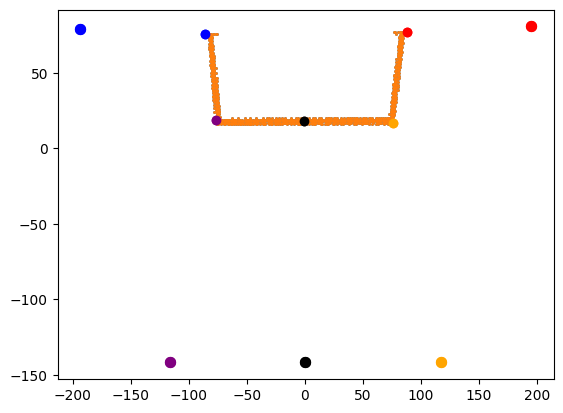

In [655]:
def y_diff(b):
    "Cette fonction prend en entrée l'ordonnée d'un point sur l'axe x=0"
    "projette deux points A et C dafinis en dehors de la fonction et calcule leur différence de y"
    "args : b (float) : ordonnée d'un point de fuite sur l'axe x=0"
    # Création d'une droite à partir du point A et du point de fuite vertical
    reg = LinearRegression().fit(
        np.array([0, A[0]]).reshape(-1, 1), np.array([b, A[1]])
    )
    aA, bA = reg.coef_[0], reg.intercept_
    # Création d'une droite à partir du point B et du point de fuite vertical
    reg = LinearRegression().fit(
        np.array([0, C[0]]).reshape(-1, 1), np.array([b, C[1]])
    )
    aC, bC = reg.coef_[0], reg.intercept_
    # Projection de A et B sur la droite de projection (y = -x)
    # Pour A intersection de OA avec y = -x
    A_ = np.array([[aA, -1], [1, 1]])
    b = np.array([-bA, 0])
    projection_A = np.linalg.solve(A_, b)
    # Pour C intersection de OB avec y = -x
    A_ = np.array([[aC, -1], [1, 1]])
    b = np.array([-bC, 0])
    projection_C = np.linalg.solve(A_, b)
    # Calcul des points résultants de ces projections
    Result_A = np.array([A[1], projection_A[1]])
    Result_C = np.array([C[1], projection_C[1]])
    # Calcul de la différence d'altitude entre les points résultatants
    y_diff = np.abs(Result_C[1] - Result_A[1])
    return y_diff


def predictv(A, C, loss):
    "Cette fonction prend en entrée un point A et un point C, d'un côté vertical de l'image, une fonction de perte loss,"
    "définit un point de fuite hypothétique en dessous du point 0"
    "projette A et C et applique sur ces points projetés une fonction de perte pour définir le point de fuite optimal"
    "args: A (np.array): les coordonnées du point supérieur du côté de l'image"
    "      C (np.array): les coordonnées du point inférieur du côté de l'image"
    "      loss (fonction): fonction de perte ('y_diff')"
    "returns: Ov (np.array): les coordonnées du point de fuite vertical"
    calcul_point_de_fuite = minimize_scalar(loss, bounds=(-1000, 0))
    return np.array([0, calcul_point_de_fuite.x])


A = labels(img_pca)[0]
C = labels(img_pca)[2]

Ov = predictv(A, C, y_diff)
Ov

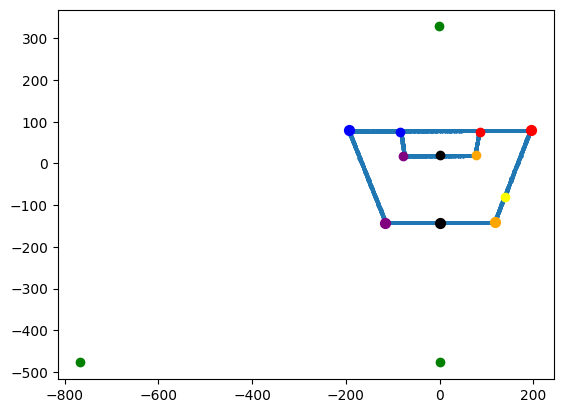

In [629]:
def predicth(labels_):
    "cette fonction calcule le point d'intersection Ov2 d'une ligne passant par le milieu J de la base"
    " et un sommet supérieur F du petit carré"
    "et la droite horizontale passant par le point de fuite horizontale Oh."
    "Ensuite elle calcule le point d'intersection F2 de Ov2I avec le côté BD du grand carré."
    "Enfin elle calcule le point de fuite horizontal, point d'intersection de FF2 avec IJ"
    "args : labels_ (np.array) : la liste des points d'intérêt de l'image"
    A, B, C, D, I, E, F, G, H, J = labels_
    # Calcul du point d'intersection Ov2 de JF avec l'horizontale passant par Oh
    # JF
    reg = LinearRegression()
    reg.fit(np.array([J[0], F[0]]).reshape(-1, 1), np.array([J[1], F[1]]))
    aJF = reg.coef_[0]
    bJF = reg.intercept_
    # OvOv2
    aOvOv2 = 0
    bOvOv2 = Ov[1]
    # Ov2, point d'intersection
    A_ = np.array([[aJF, -1], [0, 1]])
    b_ = np.array([-bJF, bOvOv2])
    Ov2 = np.linalg.solve(A_, b_)

    # On cherche le point d'intersection F2 de Ov2I avec BD
    # Ov2I
    reg = LinearRegression()
    reg.fit(np.array([Ov2[0], I[0]]).reshape(-1, 1), [Ov2[1], I[1]])
    aOv2I = reg.coef_[0]
    bOv2I = reg.intercept_
    # BD
    reg = LinearRegression()
    reg.fit(np.array([B[0], D[0]]).reshape(-1, 1), [B[1], D[1]])
    aBD = reg.coef_[0]
    bBD = reg.intercept_
    # F2
    F2 = np.linalg.solve([[aOv2I, -1], [aBD, -1]], [-bOv2I, -bBD])

    # On cherche le point d'intersection Oh de IJ avec F2F
    # F2F
    reg = LinearRegression()
    reg.fit(np.array([F2[0], F[0]]).reshape(-1, 1), [F2[1], F[1]])
    aF2F = reg.coef_[0]
    bF2F = reg.intercept_
    # Oh
    Oh = np.linalg.solve([[1, 0], [aF2F, -1]], [-I[0], -bF2F])

    # Visualisation
    plt.scatter(img_pca[:, 0], img_pca[:, 1], s=1)
    plt.scatter(A[0], A[1], color="blue", s=50)
    plt.scatter(B[0], B[1], color="red", s=50)
    plt.scatter(C[0], C[1], color="purple", s=50)
    plt.scatter(D[0], D[1], color="orange", s=50)
    plt.scatter(I[0], I[1], color="black", s=50)
    plt.scatter(E[0], E[1], color="blue")
    plt.scatter(F[0], F[1], color="red")
    plt.scatter(G[0], G[1], color="purple")
    plt.scatter(H[0], H[1], color="orange")
    plt.scatter(J[0], J[1], color="black")
    plt.scatter(Ov[0], Ov[1], color="green")
    plt.scatter(Ov2[0], Ov2[1], color="green")
    plt.scatter(Oh[0], Oh[1], color="green")
    plt.scatter(F2[0], F2[1], color="yellow")

    return Oh


Oh = predicth(labels_)

array([[-133.03798209,  303.3285956 ],
       [ 615.70546543,    5.84164804],
       [ 325.18323971,  258.47756617],
       ...,
       [  26.48433906,   30.1336003 ],
       [  27.21251385,   29.44820882],
       [  25.07077279,   30.09081699]], shape=(5083, 2))

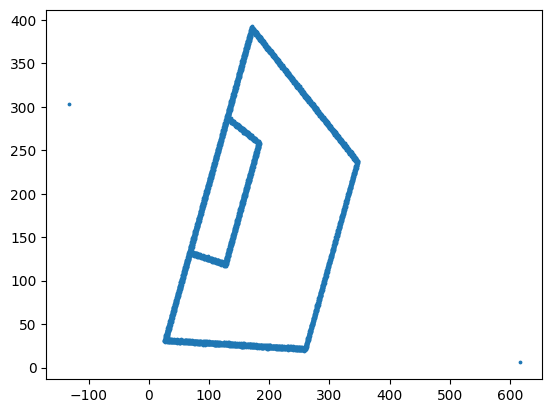

In [630]:
def inverse_transform(*args, axis=-1):
    "Cette fonction prend des liste de points et applique un pca.inverse_transform"
    "axis permet de faire une rotation de l'image au besoin"
    "args : args (np.array) : les points sur lesquels la transformation est réalisée"
    "       axis (int) : 1 ou -1, 1 laisse la figure en l'état, -1 l'inverse"
    "returns : data (np.array) : le tableau des points transformés"
    data = axis * np.vstack(args)
    data = pca.inverse_transform(data)

    # Visualisation
    plt.scatter(data[:, 0], data[:, 1], s=3)

    return data


inverse_transform(Oh, Ov, img_pca, axis=-1)

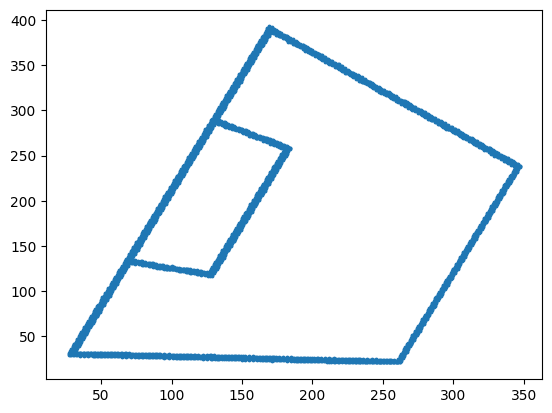

In [631]:
plt.scatter(img_points[:, 0], img_points[:, 1], s=3)

array([[119, 158],
       [120, 158],
       [123, 158],
       ...,
       [278, 219],
       [280, 219],
       [283, 219]], shape=(948, 2))

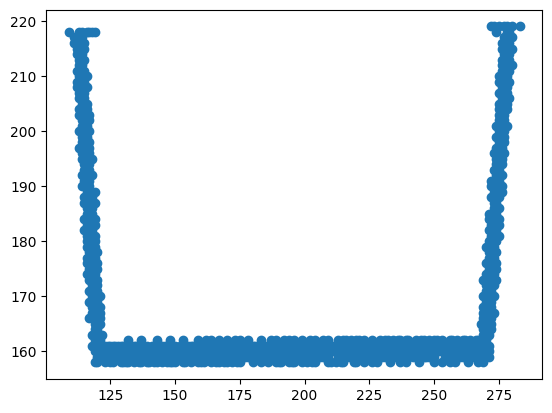

In [632]:
def erode_line_2(figure, iter):
    "Cette fonction permet d'éroder une figure. Il prend chaque colonne une par une"
    "et enlève un point d'indice de ligne max et d'indice de ligne min et retourne la figure érodée"
    "args : figure (np.array) : l'ensemble des points de la figure"
    "       iter (int): le nombre de cycle d'érosion"
    "returns : (np.array) : la figure érodée"
    fig = figure.copy()
    for i, j in product(range(iter), range(fig.shape[1])):
        try:
            sup = np.max(np.where(fig[:, j] != 1))
            inf = np.min(np.where(fig[:, j] != 1))
            fig[sup, j] = 1
            fig[inf, j] = 1
        except:
            continue
        i += 1
    return fig


def extract_cluster(img_pca, grind, eps, min_samples):
    "Cette fonction retransforme la liste des coordonnées img_pca en tableau image, pour pouvoir l'éroder avec erode_line_2"
    "Puis la retransforme en coordonnées et lui applique un dbscan pour extraire le petit parallélogramme"
    "args : img_pca (np.array) : liste des coordonnées"
    "       grind (int) : l'épaisseur d'érosion du contour"
    "       eps (int) : le rayon de la fenêtre dbscan"
    "       min_samples : l'effectif mini dans la fenêtre dbscan"
    "returns : (np.array) un tableau de coordonnées du petit parallélogramme"
    # Erosion du contour pour atteindre le petit parallélogramme
    y_coords = img_pca[:, 0].astype(int)
    x_coords = img_pca[:, 1].astype(int)

    x_coords = x_coords - np.min(x_coords)
    y_coords = y_coords - np.min(y_coords)

    # Les dimensions maximales
    max_x = np.max(x_coords) + 1
    max_y = np.max(y_coords) + 1

    # On crée un masque de 1
    tableau_2d = np.ones((max_x, max_y), dtype=int)

    # On met à 0 les coordonnées (x, y)
    tableau_2d[x_coords, y_coords] = 0

    # plt.imshow(tableau_2d)
    # On effecture l'érosion du contour
    petit_carré = erode_line_2(tableau_2d, grind)

    # On revient au format initial
    h, w = petit_carré.shape
    petit_carré = np.array(
        [[j, i] for i, j in product(range(h), range(w)) if (petit_carré[i, j] != 1)]
    )
    petit_carré[:, 0] = petit_carré[:, 0] + np.min(x_coords)
    petit_carré[:, 1] = petit_carré[:, 1] + np.min(y_coords)
    # Et un dbscan pour isoler le petit carré
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    dbscan.fit(petit_carré)

    # Visualisation
    labels = dbscan.labels_
    # scatter = plt.scatter(petit_carré[:, 0], petit_carré[:, 1], c=labels)

    # Le petit carré
    petit_carré = petit_carré[labels == 0]
    plt.scatter(petit_carré[:, 0], petit_carré[:, 1])
    return petit_carré


extract_cluster(img_pca, 3, 7, 45)